# Atividade 1

Transformar o problema multiclasse em problemas binários usando OVA e OVO. Escolha uma medida para avaliar o desempenho (acurácia, F1, etc.) e diga qual das duas abordagens se saiu melhor usando para tanto alguma técnica de validação (holdout, etc.). Use como algoritmo o de árvore.


In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from etl.kaggle_extraction import run_extraction


In [2]:
# Extraindo Dataset do Kaggle
run_extraction()
print("Kaggle extraction completed.")

data/car_evaluation.csv already exists, skipping download.
Kaggle extraction completed.


In [3]:
# Criando o Dataframe (arquivo sem cabeçalho, por isso header=None)
colunas = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv("data/car_evaluation.csv", header=None, names=colunas)

In [4]:
# Avaliando nulos
print(df.isnull().sum())

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [5]:
# Avaliando duplicados
print(df.duplicated().sum())

0


In [6]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

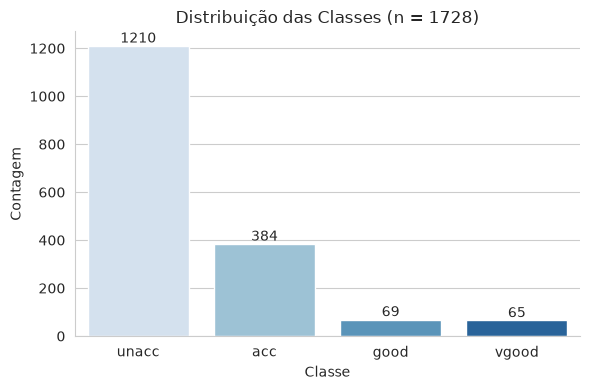

In [7]:
# Gráfico de barras para evidenciar a distribuição das classes
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

ordem_classes = ['unacc', 'acc', 'good', 'vgood']
paleta = sns.color_palette('Blues', n_colors=len(ordem_classes))

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, x='class', order=ordem_classes,
    hue='class', hue_order=ordem_classes, palette=paleta, legend=False
)

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.title(f'Distribuição das Classes (n = {len(df)})')
plt.xlabel('Classe')
plt.ylabel('Contagem')
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# Label Encoding
mapeamento = {
    'buying':   {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'maint':    {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'doors':    {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons':  {'2': 2, '4': 4, 'more': 5},
    'lug_boot': {'small': 1, 'med': 2, 'big': 3},
    'safety':   {'low': 1, 'med': 2, 'high': 3},
    'class':    {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}

# Aplicando o mapeamento no DataFrame
for coluna, mapa in mapeamento.items():
    df[coluna] = df[coluna].map(mapa)

In [9]:
# Separação em X e y
X = df.drop('class', axis=1)
y = df['class']

In [10]:
# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Definindo o modelo base de Árvore de Decisão
tree_base = DecisionTreeClassifier(random_state=42)

# Instanciando as estratégias OVA e OVO
model_ova = OneVsRestClassifier(tree_base)
model_ovo = OneVsOneClassifier(tree_base)

# Treinamento
model_ova.fit(X_train, y_train)
model_ovo.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred_ova = model_ova.predict(X_test)
y_pred_ovo = model_ovo.predict(X_test)

In [11]:
# Holdout

acc_ova = accuracy_score(y_test, y_pred_ova)
f1_ova = f1_score(y_test, y_pred_ova, average='macro')

acc_ovo = accuracy_score(y_test, y_pred_ovo)
f1_ovo = f1_score(y_test, y_pred_ovo, average='macro')

print(f"OVA (One-vs-All) -> Acurácia: {acc_ova:.4f} | F1-Score (Macro): {f1_ova:.4f}")
print(f"OVO (One-vs-One) -> Acurácia: {acc_ovo:.4f} | F1-Score (Macro): {f1_ovo:.4f}")

OVA (One-vs-All) -> Acurácia: 0.9595 | F1-Score (Macro): 0.9089
OVO (One-vs-One) -> Acurácia: 0.9750 | F1-Score (Macro): 0.9575


In [12]:
# 5-Fold Cross-Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro']

cv_results_ova = cross_validate(OneVsRestClassifier(tree_base), X, y, cv=cv, scoring=scoring)
cv_results_ovo = cross_validate(OneVsOneClassifier(tree_base), X, y, cv=cv, scoring=scoring)

acc_cv_ova = cv_results_ova['test_accuracy'].mean()
f1_cv_ova = cv_results_ova['test_f1_macro'].mean()

acc_cv_ovo = cv_results_ovo['test_accuracy'].mean()
f1_cv_ovo = cv_results_ovo['test_f1_macro'].mean()

print(f"OVA -> Acurácia Média: {acc_cv_ova:.4f} (Desvio Padrão: +/- {cv_results_ova['test_accuracy'].std():.4f})")
print(f"OVA -> F1-Macro Médio: {f1_cv_ova:.4f}")
print("-" * 50)
print(f"OVO -> Acurácia Média: {acc_cv_ovo:.4f} (Desvio Padrão: +/- {cv_results_ovo['test_accuracy'].std():.4f})")
print(f"OVO -> F1-Macro Médio: {f1_cv_ovo:.4f}")

OVA -> Acurácia Média: 0.9687 (Desvio Padrão: +/- 0.0081)
OVA -> F1-Macro Médio: 0.9272
--------------------------------------------------
OVO -> Acurácia Média: 0.9821 (Desvio Padrão: +/- 0.0085)
OVO -> F1-Macro Médio: 0.9592


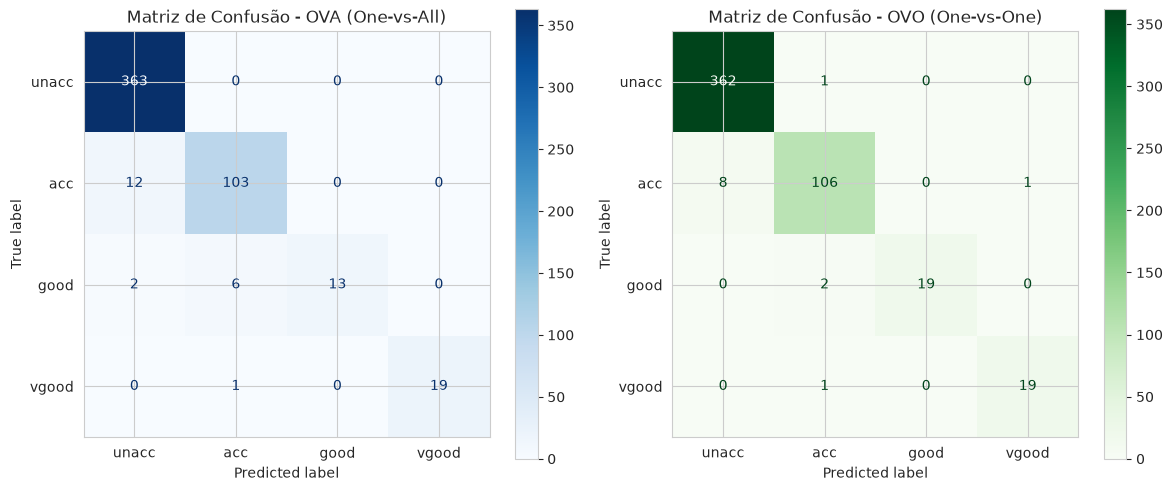

In [13]:
# Nomes das classes na ordem dos seus valores codificados (0, 1, 2, 3)
class_names = ['unacc', 'acc', 'good', 'vgood']

# Matriz de Confusão
cm_ova = confusion_matrix(y_test, y_pred_ova)
cm_ovo = confusion_matrix(y_test, y_pred_ovo)

# Plot do gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico OVA
disp_ova = ConfusionMatrixDisplay(confusion_matrix=cm_ova, display_labels=class_names)
disp_ova.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusão - OVA (One-vs-All)')

# Gráfico OVO
disp_ovo = ConfusionMatrixDisplay(confusion_matrix=cm_ovo, display_labels=class_names)
disp_ovo.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Matriz de Confusão - OVO (One-vs-One)')

plt.tight_layout()
plt.show()

In [14]:
if f1_cv_ova > f1_cv_ovo:
    print(f"A abordagem OVA (One-vs-All) obteve o melhor desempenho (F1-Macro CV: {f1_cv_ova:.4f} vs {f1_cv_ovo:.4f}).")
elif f1_cv_ovo > f1_cv_ova:
    print(f"A abordagem OVO (One-vs-One) obteve o melhor desempenho (F1-Macro CV: {f1_cv_ovo:.4f} vs {f1_cv_ova:.4f}).")
else:
    print("Ambas as abordagens obtiveram desempenhos idênticos na validação cruzada.")

A abordagem OVO (One-vs-One) obteve o melhor desempenho (F1-Macro CV: 0.9592 vs 0.9272).
